# MNIST Feedforward Quickstart

Train a dense neural network on MNIST. This is the baseline model before moving into CNNs.

## Initialize PyTorch

- Seed PyTorch and randomness for reproduceable outcomes
- Detect device (GPU, Apple Silicon, CPU)

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = get_device()
device

'mps'

## Load the Dataset

- Load MNIST handwritten digit images
- Convert images from PIL format into PyTorch tensors
- Normalize images using the MNIST mean (`0.1307`) and standard deviation (`0.3081`)
- Use one normalization value because MNIST is grayscale with one image channel
- Use smaller training and test subsets to keep the notebook fast
- Wrap the data in `DataLoader`s so PyTorch can feed batches into the model

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_data = datasets.MNIST(root="../../data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="../../data", train=False, download=True, transform=transform)

train_loader = DataLoader(Subset(train_data, range(8000)), batch_size=128, shuffle=True)
test_loader = DataLoader(Subset(test_data, range(2000)), batch_size=256)

## Define Model

- Create a feedforward neural network with PyTorch `nn.Module`
- Flatten each MNIST image from `28 x 28` pixels into `784` features
- Pass the features through two hidden layers: `128` units, then `64` units
- Use `ReLU` activations to learn non-linear patterns
- Output `10` class scores, one for each possible digit
- Move the model to the selected compute device

In [3]:
class MNISTFeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
        )

    def forward(self, x):
        return self.network(x)

model = MNISTFeedForward().to(device)
model

MNISTFeedForward(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Train Model

- Define the loss function with `CrossEntropyLoss` for multi-class classification
- Use Adam to update model parameters from backpropagation gradients
- Train for multiple epochs over the training subset
- Run a forward pass to produce raw class scores, called `logits`
- Clear old gradients, compute new gradients, and update model weights
- Track average loss and accuracy for each epoch

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(f"epoch {epoch + 1}: loss={total_loss / len(train_loader):.4f}, accuracy={correct / total:.3f}")

epoch 1: loss=0.8189, accuracy=0.782
epoch 2: loss=0.3004, accuracy=0.911
epoch 3: loss=0.2287, accuracy=0.934


## Evaluate Model

- Put the model in evaluation mode with `model.eval()`
- Disable gradient tracking with `torch.no_grad()` for faster evaluation
- Run the model on test images and choose the predicted class with `argmax`
- Count correct predictions across the test subset
- Compute final test accuracy as `correct / total`

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"test accuracy: {correct / total:.3f}")

test accuracy: 0.899


## Visualize Predictions

- Pull one batch of images and labels from the test loader
- Run the trained model on the batch without tracking gradients
- Convert model outputs into predicted digit classes with `argmax`
- Display sample images with their true labels and predicted labels

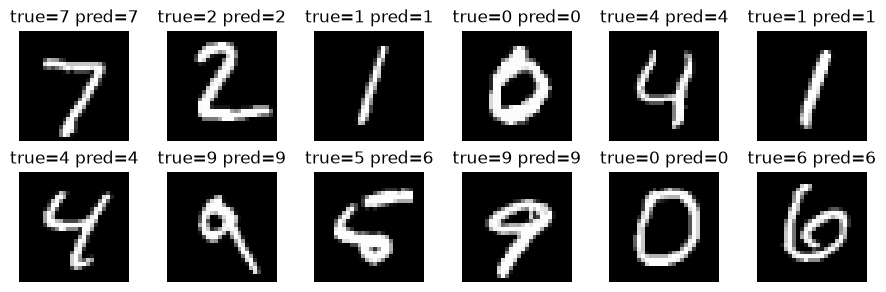

In [ ]:
images, labels = next(iter(test_loader))
with torch.no_grad():
    predictions = model(images.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(9, 3))
for ax, image, label, pred in zip(axes.ravel(), images[:12], labels[:12], predictions[:12]):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"true={label.item()} pred={pred.item()}")
    ax.axis("off")
plt.tight_layout()

## Exercise

Change the hidden layer sizes, learning rate, or number of epochs. How does the baseline accuracy change before using convolutions?